In [2]:
!git clone https://github.com/lucasfritzke/trabalho02-pln

Cloning into 'trabalho02-pln'...
remote: Enumerating objects: 145, done.
remote: Counting objects: 100% (145/145), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 145 (delta 72), reused 107 (delta 38), pack-reused 0 (from 0)
Receiving objects: 100% (145/145), 10.95 MiB | 14.13 MiB/s, done.
Resolving deltas: 100% (72/72), done.


# Classificação - Treino/Teste

## Probabilísticas

### Regressão Logística

#### Treinando e Salvando Modelo

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import joblib

df = pd.read_csv("comentarios02.csv")
df.columns = [c.strip().lower() for c in df.columns]
comentario_col = [c for c in df.columns if "conteudo_comentario" in c][0]
nota_col = [c for c in df.columns if "nota_comentario" in c][0]

df = df[[comentario_col, nota_col]].dropna()
df[nota_col] = pd.to_numeric(df[nota_col].astype(str).str.replace(",", ".", regex=False), errors="coerce").round().clip(1,2) # Quantidade de classes
df[comentario_col] = df[comentario_col].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

X_train, X_test, y_train, y_test = train_test_split(
    df[comentario_col], df[nota_col].astype(int),
    test_size=0.2, random_state=42, stratify=df[nota_col]
)

joblib.dump((X_train, X_test, y_train, y_test), 'train_test_split.pkl')

model = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, strip_accents="unicode", ngram_range=(1,2))),
    ("lr", LogisticRegression(max_iter=200, solver="lbfgs", multi_class="multinomial", class_weight="balanced"))
])

model.fit(X_train, y_train)
joblib.dump(model, "modelo_logreg.pkl")
print("Modelo Logistic Regression salvo: modelo_logreg.pkl")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


Modelo Logistic Regression salvo: modelo_logreg.pkl


#### Métricas e Teste Manual

[LogisticRegression] RMSE=0.506  MAE=0.256  ACC=0.744


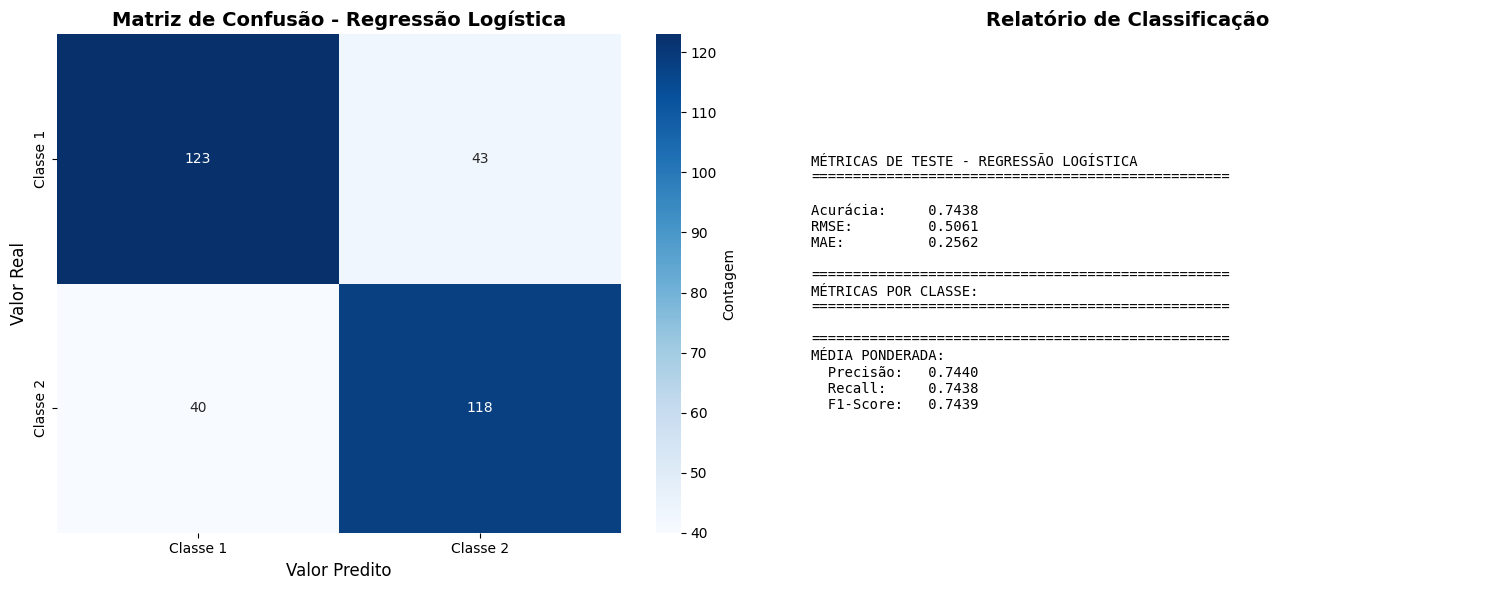


RELATÓRIO COMPLETO DE CLASSIFICAÇÃO
              precision    recall  f1-score   support

    Classe 1       0.75      0.74      0.75       166
    Classe 2       0.73      0.75      0.74       158

    accuracy                           0.74       324
   macro avg       0.74      0.74      0.74       324
weighted avg       0.74      0.74      0.74       324


EXEMPLOS DE PREDIÇÕES

Gostei muito do filme, atuação excelente e trilha sonora incrível!
 -> classe: 2 | confiança: 0.755
 -> probabilidades: {np.int64(1): 0.24542145795502215, np.int64(2): 0.7545785420449778}

Roteiro fraco e previsível, me decepcionou bastante.
 -> classe: 1 | confiança: 0.846
 -> probabilidades: {np.int64(1): 0.8461295975568431, np.int64(2): 0.1538704024431568}

É ok. Nada impressionante, mas também não é ruim.
 -> classe: 1 | confiança: 0.730
 -> probabilidades: {np.int64(1): 0.7304781622312195, np.int64(2): 0.2695218377687805}



In [5]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (mean_squared_error, mean_absolute_error, accuracy_score,
                             confusion_matrix, classification_report)

# Carregar modelo e dados
model = joblib.load("modelo_logreg.pkl")
X_train, X_test, y_train, y_test = joblib.load('train_test_split.pkl')

# Fazer predições
y_pred_lr = model.predict(X_test)

# Calcular métricas
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_lr)
acc = accuracy_score(y_test, y_pred_lr)
print(f"[LogisticRegression] RMSE={rmse:.3f}  MAE={mae:.3f}  ACC={acc:.3f}")

# Calcular matriz de confusão e relatório
conf_matrix = confusion_matrix(y_test, y_pred_lr)
classes = sorted(model.classes_)

# ===== PLOTAR MATRIZ DE CONFUSÃO E MÉTRICAS =====
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Matriz de Confusão
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Classe {c}' for c in classes],
            yticklabels=[f'Classe {c}' for c in classes],
            ax=axes[0], cbar_kws={'label': 'Contagem'})
axes[0].set_title('Matriz de Confusão - Regressão Logística', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Valor Real', fontsize=12)
axes[0].set_xlabel('Valor Predito', fontsize=12)

# Plot 2: Métricas detalhadas
report = classification_report(y_test, y_pred_lr, output_dict=True)
metrics_text = f"""
MÉTRICAS DE TESTE - REGRESSÃO LOGÍSTICA
{'='*50}

Acurácia:     {acc:.4f}
RMSE:         {rmse:.4f}
MAE:          {mae:.4f}

{'='*50}
MÉTRICAS POR CLASSE:
{'='*50}
"""

for cls in classes:
    cls_str = str(float(cls))
    if cls_str in report:
        metrics_text += f"""
CLASSE {cls}:
  Precisão:   {report[cls_str]['precision']:.4f}
  Recall:     {report[cls_str]['recall']:.4f}
  F1-Score:   {report[cls_str]['f1-score']:.4f}
  Suporte:    {int(report[cls_str]['support'])}
"""

metrics_text += f"""
{'='*50}
MÉDIA PONDERADA:
  Precisão:   {report['weighted avg']['precision']:.4f}
  Recall:     {report['weighted avg']['recall']:.4f}
  F1-Score:   {report['weighted avg']['f1-score']:.4f}
"""

axes[1].text(0.05, 0.5, metrics_text, fontsize=10, family='monospace',
             verticalalignment='center', transform=axes[1].transAxes)
axes[1].axis('off')
axes[1].set_title('Relatório de Classificação', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Imprimir relatório completo no console
print("\n" + "="*60)
print("RELATÓRIO COMPLETO DE CLASSIFICAÇÃO")
print("="*60)
print(classification_report(y_test, y_pred_lr,
                           target_names=[f'Classe {c}' for c in classes]))

# Função de predição individual
def predict_one_lr(text: str):
    proba = model.predict_proba([text])[0]
    idx = int(np.argmax(proba))
    classes_model = model.classes_
    return classes_model[idx], float(proba[idx]), dict(zip(classes_model, proba.tolist()))

# Exemplos de predição
print("\n" + "="*60)
print("EXEMPLOS DE PREDIÇÕES")
print("="*60)
texts = [
    "Gostei muito do filme, atuação excelente e trilha sonora incrível!",
    "Roteiro fraco e previsível, me decepcionou bastante.",
    "É ok. Nada impressionante, mas também não é ruim."
]
for t in texts:
    label, conf, probs = predict_one_lr(t)
    print(f"\n{t}")
    print(f" -> classe: {label} | confiança: {conf:.3f}")
    print(f" -> probabilidades: {probs}")

print("\n" + "="*60)

### Naive Bayes

#### Treinando e Salvando Modelo

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion
import joblib

df = pd.read_csv("comentarios02.csv")

df.columns = [c.strip().lower() for c in df.columns]
comentario_col = [c for c in df.columns if "conteudo_comentario" in c][0]
nota_col = [c for c in df.columns if "nota_comentario" in c][0]

df = df[[comentario_col, nota_col]].dropna()
df[nota_col] = pd.to_numeric(df[nota_col].astype(str).str.replace(",", ".", regex=False), errors="coerce").round().clip(1,2) # Quantidade de classes
df[comentario_col] = df[comentario_col].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

X_train, X_test, y_train, y_test = train_test_split(
    df[comentario_col], df[nota_col].astype(int),
    test_size=0.2, random_state=42, stratify=df[nota_col]
)

tfidf_union = FeatureUnion([
    ("word", TfidfVectorizer(strip_accents="unicode", lowercase=True)),
    ("char", TfidfVectorizer(analyzer="char_wb"))
])

pipe_nb = Pipeline([
    ("tfidf", tfidf_union),
    ("nb", MultinomialNB())
])

param_grid = {
    "tfidf__word__ngram_range": [(1,1), (1,2)],
    "tfidf__word__min_df": [1,2],
    "tfidf__char__ngram_range": [(3,5), (3,6)],
    "tfidf__char__min_df": [1,2],
    "nb__alpha": [0.1, 0.3, 0.5, 1.0]
}

grid = GridSearchCV(
    pipe_nb,
    param_grid,
    cv=3,
    n_jobs=-1,
    scoring="accuracy",
    verbose=1
)
grid.fit(X_train, y_train)

best_nb = grid.best_estimator_
joblib.dump(best_nb, "modelo_naivebayes.pkl")
model = best_nb
print(f"Modelo Naive Bayes salvo: modelo_naivebayes.pkl  (best params: {grid.best_params_})")

Fitting 3 folds for each of 64 candidates, totalling 192 fits
Modelo Naive Bayes salvo: modelo_naivebayes.pkl  (best params: {'nb__alpha': 0.1, 'tfidf__char__min_df': 1, 'tfidf__char__ngram_range': (3, 5), 'tfidf__word__min_df': 1, 'tfidf__word__ngram_range': (1, 2)})


#### Métricas e Teste Manual

[NaiveBayes] RMSE=0.506  MAE=0.256  ACC=0.744


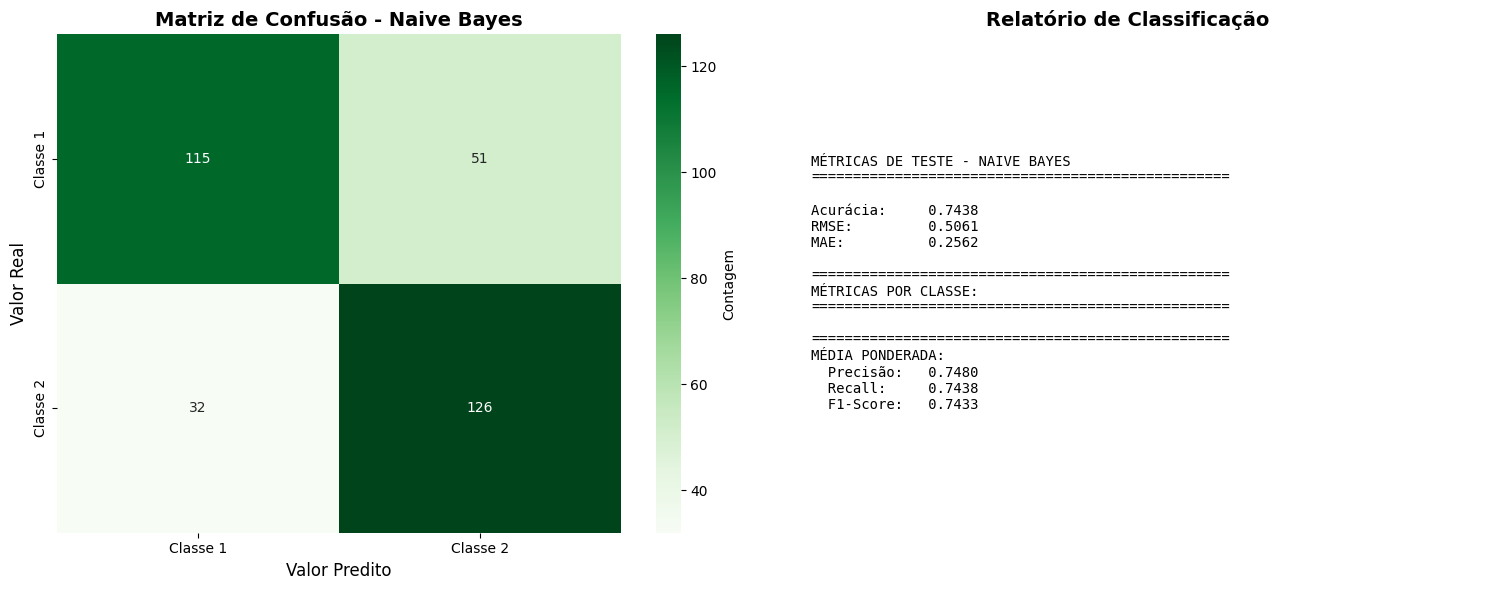


RELATÓRIO COMPLETO DE CLASSIFICAÇÃO
              precision    recall  f1-score   support

    Classe 1       0.78      0.69      0.73       166
    Classe 2       0.71      0.80      0.75       158

    accuracy                           0.74       324
   macro avg       0.75      0.75      0.74       324
weighted avg       0.75      0.74      0.74       324


EXEMPLOS DE PREDIÇÕES

Gostei muito do filme, atuação excelente e trilha sonora incrível!
 -> classe: 2 | confiança: 0.997
 -> probabilidades: {np.int64(1): 0.003241566628060274, np.int64(2): 0.9967584333719257}

Roteiro fraco e previsível, me decepcionou bastante.
 -> classe: 1 | confiança: 1.000
 -> probabilidades: {np.int64(1): 0.9997723766531695, np.int64(2): 0.0002276233468350823}

É ok. Nada impressionante, mas também não é ruim.
 -> classe: 1 | confiança: 0.890
 -> probabilidades: {np.int64(1): 0.8898848539397093, np.int64(2): 0.11011514606028856}



In [7]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (mean_squared_error, mean_absolute_error, accuracy_score,
                             confusion_matrix, classification_report)

# Carregar modelo e dados
model = joblib.load("modelo_naivebayes.pkl")
X_train, X_test, y_train, y_test = joblib.load('train_test_split.pkl')

# Fazer predições
y_pred_nb = model.predict(X_test)

# Calcular métricas
mse = mean_squared_error(y_test, y_pred_nb)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_nb)
acc = accuracy_score(y_test, y_pred_nb)
print(f"[NaiveBayes] RMSE={rmse:.3f}  MAE={mae:.3f}  ACC={acc:.3f}")

# Calcular matriz de confusão e relatório
conf_matrix = confusion_matrix(y_test, y_pred_nb)
classes = sorted(model.classes_)

# ===== PLOTAR MATRIZ DE CONFUSÃO E MÉTRICAS =====
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Matriz de Confusão
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=[f'Classe {c}' for c in classes],
            yticklabels=[f'Classe {c}' for c in classes],
            ax=axes[0], cbar_kws={'label': 'Contagem'})
axes[0].set_title('Matriz de Confusão - Naive Bayes', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Valor Real', fontsize=12)
axes[0].set_xlabel('Valor Predito', fontsize=12)

# Plot 2: Métricas detalhadas
report = classification_report(y_test, y_pred_nb, output_dict=True)
metrics_text = f"""
MÉTRICAS DE TESTE - NAIVE BAYES
{'='*50}

Acurácia:     {acc:.4f}
RMSE:         {rmse:.4f}
MAE:          {mae:.4f}

{'='*50}
MÉTRICAS POR CLASSE:
{'='*50}
"""

for cls in classes:
    cls_str = str(float(cls))
    if cls_str in report:
        metrics_text += f"""
CLASSE {cls}:
  Precisão:   {report[cls_str]['precision']:.4f}
  Recall:     {report[cls_str]['recall']:.4f}
  F1-Score:   {report[cls_str]['f1-score']:.4f}
  Suporte:    {int(report[cls_str]['support'])}
"""

metrics_text += f"""
{'='*50}
MÉDIA PONDERADA:
  Precisão:   {report['weighted avg']['precision']:.4f}
  Recall:     {report['weighted avg']['recall']:.4f}
  F1-Score:   {report['weighted avg']['f1-score']:.4f}
"""

axes[1].text(0.05, 0.5, metrics_text, fontsize=10, family='monospace',
             verticalalignment='center', transform=axes[1].transAxes)
axes[1].axis('off')
axes[1].set_title('Relatório de Classificação', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Imprimir relatório completo no console
print("\n" + "="*60)
print("RELATÓRIO COMPLETO DE CLASSIFICAÇÃO")
print("="*60)
print(classification_report(y_test, y_pred_nb,
                           target_names=[f'Classe {c}' for c in classes]))

# Função de predição individual
def predict_one_nb(text: str):
    proba = model.predict_proba([text])[0]
    idx = int(np.argmax(proba))
    classes_model = model.classes_
    return classes_model[idx], float(proba[idx]), dict(zip(classes_model, proba.tolist()))

# Exemplos de predição
print("\n" + "="*60)
print("EXEMPLOS DE PREDIÇÕES")
print("="*60)
texts = [
    "Gostei muito do filme, atuação excelente e trilha sonora incrível!",
    "Roteiro fraco e previsível, me decepcionou bastante.",
    "É ok. Nada impressionante, mas também não é ruim."
]
for t in texts:
    label, conf, probs = predict_one_nb(t)
    print(f"\n{t}")
    print(f" -> classe: {label} | confiança: {conf:.3f}")
    print(f" -> probabilidades: {probs}")

print("\n" + "="*60)

## Redes Neurais

### BERT

#### Carregando Dados

In [ ]:
# espera df['comentario'], df['nota']

import pandas as pd

df = pd.read_csv("comentarios02.csv")
df = pd.DataFrame({
    "comentario": df["conteudo_comentario"].astype(str).str.replace(r"\s+"," ",regex=True).str.strip(),
    "nota": pd.to_numeric(df["nota_comentario"].astype(str).str.replace(",",".",regex=False), errors="coerce")
})
df["nota"] = df["nota"].round().clip(1,2) # Quantidade de classes

#### Treinando Rede Neural - BERT

In [ ]:
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

model_name = "neuralmind/bert-base-portuguese-cased"
max_len = 256
batch_size = 16
epochs = 3
lr = 2e-5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

class TextRegDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = list(texts)
        self.labels = np.array(labels, dtype=np.float32)
        self.tok = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        enc = self.tok(
            self.texts[i],
            truncation=True, padding="max_length", max_length=self.max_len,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k,v in enc.items()}
        item["label"] = torch.tensor(self.labels[i], dtype=torch.float32)
        return item

X_train, X_test, y_train, y_test = train_test_split(
    df["comentario"], df["nota"], test_size=0.2, random_state=42, stratify=df["nota"]
)
train_ds = TextRegDataset(X_train, y_train, tokenizer, max_len)
test_ds  = TextRegDataset(X_test,  y_test,  tokenizer, max_len)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

class BERTRegressor(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden = self.bert.config.hidden_size
        self.dropout = nn.Dropout(0.1)
        self.head = nn.Linear(hidden, 1)

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = out.last_hidden_state
        mask = attention_mask.unsqueeze(-1)
        masked = last_hidden * mask
        pooled = masked.sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        x = self.dropout(pooled)
        return self.head(x).squeeze(-1)

model = BERTRegressor(model_name).to(device)

optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)
loss_fn = nn.MSELoss()

for epoch in range(epochs):
    model.train()
    running = 0.0
    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attn      = batch["attention_mask"].to(device)
        labels    = batch["label"].to(device).float()

        preds = model(input_ids=input_ids, attention_mask=attn)
        loss = loss_fn(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        running += loss.item()
    print(f"Epoch {epoch+1}/{epochs} - Loss: {running/len(train_loader):.4f}")

model.eval()
preds, trues = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attn      = batch["attention_mask"].to(device)
        labels    = batch["label"].to(device).float()

        out = model(input_ids=input_ids, attention_mask=attn)
        preds.extend(out.detach().cpu().numpy().tolist())
        trues.extend(labels.detach().cpu().numpy().tolist())

rmse = mean_squared_error(trues, preds)
mae  = mean_absolute_error(trues, preds)
print(f"[BERT] RMSE={rmse:.3f}  MAE={mae:.3f}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Epoch 1/3 - Loss: 0.5168
Epoch 2/3 - Loss: 0.1827
Epoch 3/3 - Loss: 0.1531
[BERT] RMSE=0.175  MAE=0.346


#### Salvando Modelo

In [ ]:
torch.save(model.state_dict(), "bert_regressor.pt")
print("Modelo salvo em: bert_regressor.pt")

Modelo salvo em: bert_regressor.pt


#### Carregando Modelo e Testando

In [ ]:
model = BERTRegressor(model_name).to(device)
model.load_state_dict(torch.load("bert_regressor.pt", map_location=device))
model.eval()

def predict_one_bert(text: str, max_length: int = 256):
    enc = tokenizer(text, truncation=True, padding="max_length",
                    max_length=max_length, return_tensors="pt")
    with torch.no_grad():
        out = model(input_ids=enc["input_ids"].to(device),
                    attention_mask=enc["attention_mask"].to(device))
    val = float(out.squeeze().item())
    stars = int(np.clip(np.rint(val), 1, 2)) # Quantidade de classes
    return val, stars

raw, s = predict_one_bert("Até que eu gostei do filme")
print(raw, s)

texts = [
    "Gostei muito do filme, atuação excelente e trilha sonora incrível!",
    "Roteiro fraco e previsível, me decepcionou bastante.",
    "É ok. Nada impressionante, mas também não é ruim."
]
for t in texts:
    val, stars = predict_one_bert(t)
    print(f"{t}\n -> valor (contínuo): {val:.3f} | classe (arredondada 1-5): {stars}\n")

1.3586199283599854 1
Gostei muito do filme, atuação excelente e trilha sonora incrível!
 -> valor (contínuo): 1.675 | classe (arredondada 1-5): 2

Roteiro fraco e previsível, me decepcionou bastante.
 -> valor (contínuo): 1.068 | classe (arredondada 1-5): 1

É ok. Nada impressionante, mas também não é ruim.
 -> valor (contínuo): 1.015 | classe (arredondada 1-5): 1



# Matrizes de Confusão e Relatórios de Classificação

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np


def plot_confusion_and_report(y_true, y_pred, labels=None, title="Confusion Matrix"):
    """Plota uma matriz de confusão com seaborn e imprime classification_report."""
    if labels is None:
        labels = sorted(list(set(y_true) | set(y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predito')
    plt.ylabel('Verdadeiro')
    plt.title(title)
    plt.tight_layout()
    plt.show()
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))


BERT - Matriz de Confusão (predições arredondadas para 1-5)


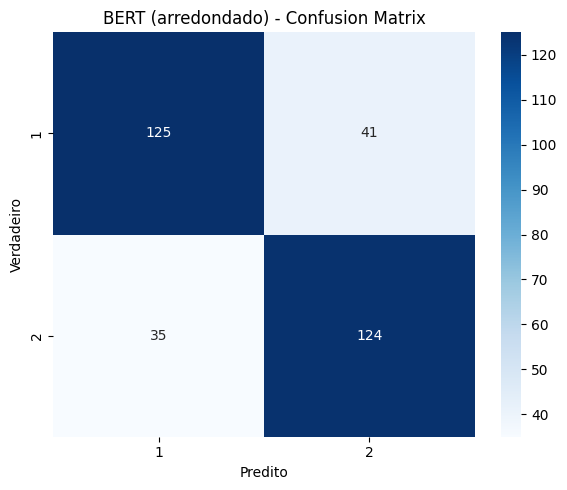


Classification Report:
              precision    recall  f1-score   support

           1       0.78      0.75      0.77       166
           2       0.75      0.78      0.77       159

    accuracy                           0.77       325
   macro avg       0.77      0.77      0.77       325
weighted avg       0.77      0.77      0.77       325



In [ ]:
# BERT - já existe 'preds' e 'trues' nas células acima (preds são float contínuos)
try:
    print("BERT - Matriz de Confusão (predições arredondadas para 1-5)")
    y_pred_bert = [int(np.clip(np.rint(v), 1, 2)) for v in preds] # Quantidade de classes
    y_true_bert = [int(np.clip(np.rint(v), 1, 2)) for v in trues] # Quantidade de classes
    labels = [1, 2] # Quantidade de classes
    plot_confusion_and_report(y_true_bert, y_pred_bert, labels=labels, title='BERT (arredondado) - Confusion Matrix')
except Exception as e:
    print("Não foi possível gerar a matriz de confusão para BERT:", e)


Logistic Regression - Matriz de Confusão


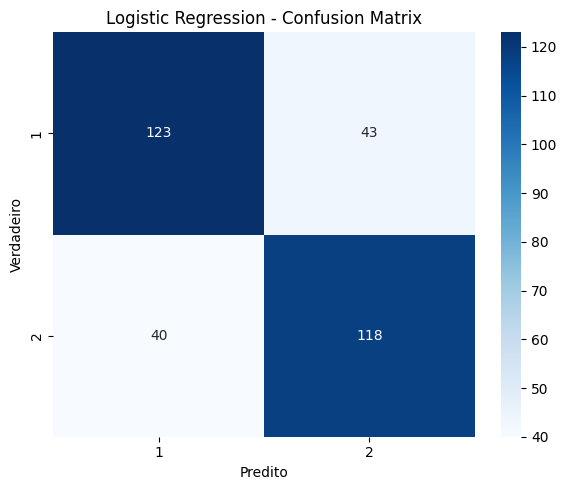


Classification Report:
              precision    recall  f1-score   support

           1       0.75      0.74      0.75       166
           2       0.73      0.75      0.74       158

    accuracy                           0.74       324
   macro avg       0.74      0.74      0.74       324
weighted avg       0.74      0.74      0.74       324

Naive Bayes - Matriz de Confusão


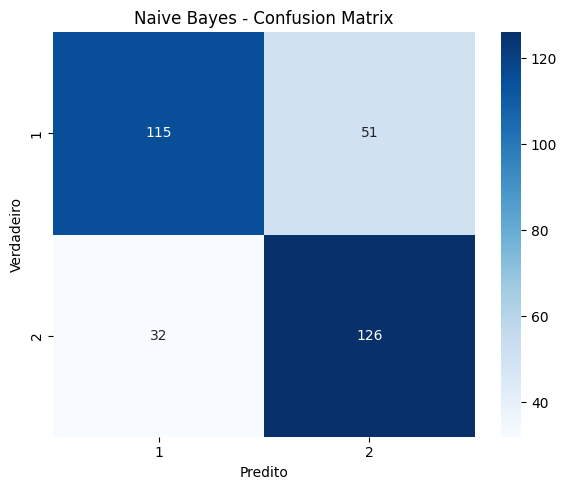


Classification Report:
              precision    recall  f1-score   support

           1       0.78      0.69      0.73       166
           2       0.71      0.80      0.75       158

    accuracy                           0.74       324
   macro avg       0.75      0.75      0.74       324
weighted avg       0.75      0.74      0.74       324



In [ ]:
import joblib

joblib.dump((X_train, X_test, y_train, y_test), 'train_test_split.pkl')

# Agora plotamos individualmente, garantindo que cada modelo use suas previsões corretas
try:
    labels = [1,2]
    print("Logistic Regression - Matriz de Confusão")
    plot_confusion_and_report(y_test.tolist() if hasattr(y_test, 'tolist') else list(y_test),
                               y_pred_lr.tolist() if hasattr(y_pred_lr, 'tolist') else list(y_pred_lr),
                               labels=labels,
                               title='Logistic Regression - Confusion Matrix')
except Exception as e:
    print("Não foi possível gerar a matriz de confusão para Logistic Regression:", e)

try:
    labels = [1,2]
    print("Naive Bayes - Matriz de Confusão")
    plot_confusion_and_report(y_test.tolist() if hasattr(y_test, 'tolist') else list(y_test),
                               y_pred_nb.tolist() if hasattr(y_pred_nb, 'tolist') else list(y_pred_nb),
                               labels=labels,
                               title='Naive Bayes - Confusion Matrix')
except Exception as e:
    print("Não foi possível gerar a matriz de confusão para Naive Bayes:", e)
